In [2]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [3]:
from omfit_classes import omfit_eqdsk

In [10]:
from netCDF4 import Dataset
import matplotlib.pyplot as pyplot
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os


In [49]:
def plot(self,gEQDSK=None, showSlowFast=False):
 with pyplot.style.context('default'):
    fig = pyplot.gcf()
    fig.set_size_inches(16, 8)
    ax0 = pyplot.subplot(131)
    if gEQDSK is None:
        gEQDSK = {}
        gEQDSK['RHORZ'] = self['eqdsk_psi']['data']
        gEQDSK['R'] = self['eqdsk_r']['data']
        gEQDSK['Z'] = self['eqdsk_z']['data']
        n = 10
        flx = fluxSurfaces(
            Rin=self['eqdsk_r']['data'],
            Zin=self['eqdsk_z']['data'],
            PSIin=self['eqdsk_psi']['data'],
            Btin=self['eqdsk_psi']['data'] * 0,
            levels=n,
            quiet=True,
            cocosin=1,
        )
        for k in range(n):
            pyplot.plot(flx['flux'][k]['R'], flx['flux'][k]['Z'], 'k', linewidth=0.5)
        pyplot.xlabel('R')
        pyplot.ylabel('Z')
    else:
        gEQDSK.plot(only2D=True)
        flx = gEQDSK['fluxSurfaces']
    pyplot.title('Ray trajectories')
    rho = self['rho_bin_center'][:]
    powden = self['powden'][:]
    powden_e = self['powden_e'][:]
    powden_i = self['powden_i'][:]
    powtot_e = self['powtot_e'][:]
    powtot_i = self['powtot_i'][:]
    powtot = self['power_total'][:]
    cur_parallel = self['s_cur_den_parallel'][:]
    curtotal_parallel = self['parallel_cur_total'][:]
    powden = powden / 1e7  # ergs/sec/cm^3 to W/cm^3 = MW/m^3
    powden_e = powden_e / 1e7  # ergs/sec/cm^3 to W/cm^3 = MW/m^3
    powden_i = powden_i / 1e7  # ergs/sec/cm^3 to W/cm^3 = MW/m^3
    powtot_elec = powtot_e / 1e7 / 1e6  # from ergs/sec to W, and to MW
    powtot_ions = powtot_i / 1e7 / 1e6
    powtot = powtot / 1e7 / 1e6
    cur_parallel = cur_parallel / 1e2  # from A/cm^2 to MA/m^2
    curtotal_parallel = curtotal_parallel / 1e3  # from A to kA
    npar = self['wnpar'][:].flatten()
    wr_vals = self['wr'][:].flatten()
    wz_vals = self['wz'][:].flatten()
    wphi_vals = self['wphi'][:].flatten()
    rho_ray = self['spsi'][:].flatten()
    btot_ray = self['sbtot'][:].flatten()
    dpol = self['ws'][:].flatten()
    dpol = dpol / 1e2  # from cm to m
    wr_vals = wr_vals / 1e2  # from cm to m
    wz_vals = wz_vals / 1e2  # from cm to m
    raypower = self['delpwr'][:].flatten()
    raypower = raypower / 1e7 / 1e6  # from ergs/sec to W, and to MW
    deriv_raypower = abs(np.gradient(raypower, dpol))  # in MW/m
    deriv_raypower[np.isinf(deriv_raypower)] = 0
    dpolmax = max(dpol)
    wr_vals[wr_vals == 0] = np.nan
    wz_vals[wz_vals == 0] = np.nan
    wphi_vals[wphi_vals == 0] = np.nan
    dpol[dpol == 0] = np.nan
    ray_Te = self['ste'][:].flatten()
    vpar = 3e10 / abs(npar)
    vthe = 4.19e7 * np.sqrt(2 * ray_Te * 1e3)  # ray_Te was in keV, using sqrt(2Te/m) as thermal velocity
    # ax0 = pyplot.subplot(131)
    pyplot.scatter(wr_vals, wz_vals, c='k', edgecolor='None', s=deriv_raypower / max(deriv_raypower) * 200, marker=',', alpha=0.1)
    myplot = pyplot.scatter(wr_vals, wz_vals, c=(raypower / max(raypower)), cmap='rainbow', edgecolor='None', marker='.')
    pyplot.xlabel('R (m)')
    pyplot.ylabel('Z (m)')
    pyplot.title('Ray trajectory')
    pyplot.axis('image')
    #pyplot.colorbar(myplot, ax=ax0, norm=raypower, label='Power in ray (MW)')
    ax0 = pyplot.subplot(232)
    angles = np.arange(0, 6.3, 0.05)
    pyplot.scatter(
        wr_vals * np.cos(wphi_vals),
        wr_vals * np.sin(wphi_vals),
        c='k',
        edgecolor='None',
        s=deriv_raypower / max(deriv_raypower) * 200,
        marker=',',
        alpha=0.1,
    )
    myplot = pyplot.scatter(
        wr_vals * np.cos(wphi_vals),
        wr_vals * np.sin(wphi_vals),
        c=(raypower / max(raypower)),
        cmap='rainbow',
        edgecolor='None',
        marker='.',
    )
    Rmax_psin1 = max(flx['geo']['Rmax_centroid'])
    R_psin0 = min(flx['geo']['Rmax_centroid'])
    Rmin_psin1 = min(flx['geo']['Rmin_centroid'])
    pyplot.plot(Rmax_psin1 * np.cos(angles), Rmax_psin1 * np.sin(angles), 'k')
    pyplot.plot(R_psin0 * np.cos(angles), R_psin0 * np.sin(angles), 'k', linestyle='dashed')
    pyplot.plot(Rmin_psin1 * np.cos(angles), Rmin_psin1 * np.sin(angles), 'k')
    pyplot.xlabel('X (m)')
    pyplot.ylabel('Y (m)')
    pyplot.title('Ray trajectory')
    pyplot.axis('image')
    pyplot.colorbar(myplot, ax=ax0, norm=raypower, label='Power in ray (MW)')
    ax = pyplot.subplot(235)
    ax.clear()
    pyplot.plot(rho, powden, label='Total {:.2f} MW'.format(powtot), linewidth=1.5)
    pyplot.plot(rho, powden_e, label='Electrons {:.2f} MW'.format(powtot_elec), linewidth=1.5)
    pyplot.plot(rho, powden_i, label='Ions {:.2f} MW'.format(powtot_ions), linewidth=1.5)
    pyplot.legend(fontsize='medium', framealpha=0.2, frameon=0, loc='upper left')
    pyplot.xlabel('$\\rho$')
    pyplot.ylabel('Power density (MW/m$^3$)')
    pyplot.axis('tight')
    ax2 = ax.twinx()
    pyplot.plot(rho, cur_parallel, color='darkorange', label='$J_\parallel$ {:.1f} kA'.format(curtotal_parallel), linewidth=1.5)
    pyplot.ylabel('$J_\parallel$ (MA/m$^2$)')
    pyplot.title('$P_{abs}$ & CD')
    pyplot.legend(fontsize='medium', framealpha=0.2, frameon=0, loc='upper right')
    pyplot.axis('tight')
    ax3 = pyplot.subplot(233)
    ax3.clear()
    pyplot.plot(dpol, npar, c='r', label='Rainbow line: $n_\parallel$', linewidth=0)
    pyplot.scatter(dpol, npar, c='k', edgecolor='none', marker='.', s=deriv_raypower / max(deriv_raypower) * 1000, alpha=0.1)
    pyplot.scatter(dpol, npar, c=(raypower / max(raypower)), cmap='rainbow', edgecolor='none', marker='.')
    pyplot.xlabel('Distance along ray (m)')
    pyplot.ylabel('$n_\parallel$')
    ax4 = ax3.twinx()
    pyplot.plot(dpol, vpar / vthe, c='g', label='Green line: $v_\\parallel/v_{th,e}$', linewidth=0)
    pyplot.scatter(dpol, vpar / vthe, c='g', edgecolor='none', marker='.', s=deriv_raypower / max(deriv_raypower) * 1000, alpha=0.1)
    pyplot.plot(dpol, vpar / vthe, c='g')
    pyplot.ylabel('$v_\\parallel/v_{th,e}$')
    pyplot.xlim(0, dpolmax)
    pyplot.title('Green line: $v_\\parallel/v_{th,e}$  Rainbow line: $n_\parallel$')
    pyplot.axis('tight')
    ax5 = pyplot.subplot(236)
    pyplot.plot(vpar / vthe, deriv_raypower, c='b')
    pyplot.xlabel('$v_\\parallel/v_{th,e}$')
    pyplot.ylabel('Ray absorption (MW/m)')
    pyplot.xlim(0, 5)
    pyplot.subplots_adjust(hspace=0.4, left=0.03, wspace=0.4, right=0.95)


In [50]:
#get files
for sim_index in [0]:

    cwd = os.getcwd()
    SCAN_dir = cwd+'/SCAN'
    work_dir = SCAN_dir+'/work'
    
    fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
    ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'

    genray_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_lh_')]
    lhfile = work_dir+'/'+genray_dir[0]+'/genray.nc'

    rootgrp = Dataset(ffile)
    geqdsk = omfit_eqdsk.OMFITgeqdsk(gfile)
    lhgrp = Dataset(lhfile)

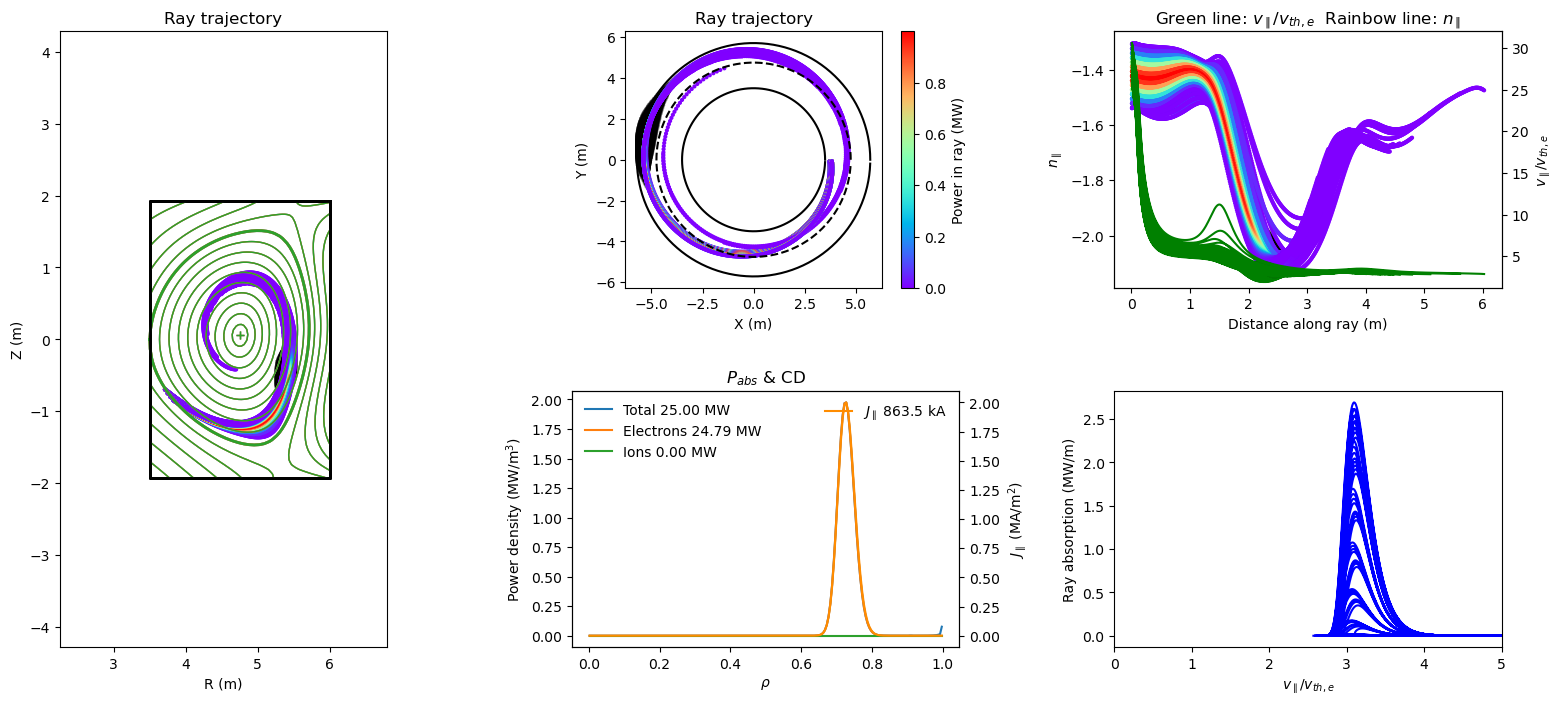

In [51]:
plot(lhgrp,gEQDSK=geqdsk)
pyplot.show()

In [42]:
print(lhgrp['wr'])

<class 'netCDF4._netCDF4.Variable'>
float64 wr(nrays, neltmax)
    long_name: major radius
    units: cms
unlimited dimensions: 
current shape = (60, 603)
filling on, default _FillValue of 9.969209968386869e+36 used
